# Ray tracing and HMC with PyTorch

In [2]:
#Download raytrace_torch.py locally if it is not already present
#Required if running on Colab
!curl -O https://api.bitbucket.org/2.0/repositories/pbehroozi/ray-tracing-sampler/src/main/raytrace_torch.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 22833  100 22833    0     0  25594      0 --:--:-- --:--:-- --:--:-- 25597


In [3]:
import torch
import sys
sys.path.append('..') #if running from repository
from raytrace_torch import sample_raytrace, sample_hamiltonian

@torch.compile
def gaussian(x):
    return -0.5*((x*x).sum())

torch.manual_seed(0)
x0 = torch.normal(0,1,[10000])
chain,likelihood = sample_raytrace(params_init=x0, \
    log_prob_fn=gaussian, n_steps=1000, n_leapfrog_steps=10, \
    step_size=0.17, refresh_rate=0.0, metro_check=1, sample_hmc=False)

Accepted: 73.800000%


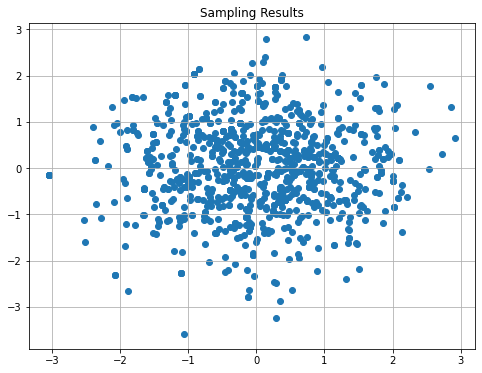

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(chain[:,0], chain[:,1])
plt.title('Sampling Results')
plt.grid()
plt.show()

In [5]:
import numpy

@torch.compile
def target_gaussian(x):
    return -0.5*((x*x).sum())

@torch.compile
def target_rosenbrock(x):
    return -(100.0*(x[1::2] - x[0::2]**2.0)**2.0 + (1 - x[0::2])**2.0).sum()

@torch.compile
def target_cauchy(x):
    return -torch.log(1+x*x).sum()

def save_chain(chain,filename, likelihood):
    chain_np = chain.cpu().detach().numpy()
    likelihood_np = likelihood.cpu().detach().numpy()
    numpy.savetxt(filename,numpy.hstack((chain_np, likelihood_np[:, None])))

def run_pdf_tests(target_pdf, length_hmc, hmc_steps, length_rt, raytrace_steps, init_sd):
    #HMC
    name = target_pdf.__name__
    max_steps = 100
    print("HMC:")
    n_steps = 4000
    if (name=='target_rosenbrock'):
        n_steps = 10000
    if (name=='target_cauchy'):
         n_steps = 200000
    for dims,step in hmc_steps.items():
        torch.manual_seed(0)
        params_init = torch.normal(0,init_sd,[dims])
        max_steps = int(length_hmc/step)
        chain,likelihood = sample_hamiltonian(params_init, target_pdf, n_steps=4000, n_leapfrog_steps=max_steps, step_size=float(step))
        chain,likelihood = sample_hamiltonian(chain[-1].clone().detach(), target_pdf, n_steps=n_steps, n_leapfrog_steps=max_steps, step_size=float(step))
        save_chain(chain, "hmc_"+name+"_"+str(dims)+"d_"+str(max_steps)+"steps.dat",likelihood)
    print("\nRaytracing:")
    for dims,step in raytrace_steps.items():
        torch.manual_seed(0)
        params_init = torch.normal(0,init_sd,[dims])
        max_steps = int(length_rt/step)
        chain,likelihood = sample_raytrace(params_init, target_pdf, n_steps=4000, n_leapfrog_steps=max_steps, step_size=float(step))
        chain,likelihood = sample_raytrace(chain[-1].clone().detach(), target_pdf, n_steps=n_steps, n_leapfrog_steps=max_steps, step_size=float(step))
        save_chain(chain, "raytrace_"+name+"_"+str(dims)+"d_"+str(max_steps)+"steps.dat",likelihood)

In [6]:
run_pdf_tests(target_gaussian, 1.57, {2:0.67, 10:0.5, 100:0.36, 1000:0.21, 10000:0.15}, 
              1.57, {2:0.71, 10:0.71, 100:0.52, 1000:0.26, 10000:0.17}, 1)

HMC:
Accepted: 94.025000%
Accepted: 94.250000%
Accepted: 92.500000%
Accepted: 92.100000%
Accepted: 86.650000%
Accepted: 85.950000%
Accepted: 85.675000%
Accepted: 85.450000%
Accepted: 77.575000%
Accepted: 79.350000%

Raytracing:
Accepted: 91.750000%
Accepted: 92.125000%
Accepted: 87.650000%
Accepted: 86.350000%
Accepted: 78.075000%
Accepted: 76.600000%
Accepted: 82.700000%
Accepted: 82.350000%
Accepted: 74.850000%
Accepted: 76.100000%


You may also try other functions above; empirically, the JAX versions seem much faster than the PyTorch versions for all but the simplest test (Gaussian) above.